In [1]:
import cobra
from cobra.flux_analysis import production_envelope
# Load iBag597 SBML model file
model = cobra.io.read_sbml_model("ModelFiles/iBag597.xml")

In [2]:
import matplotlib.pyplot as plt

In [3]:
# Quick check to ensure it loaded properly
print(f"Model: {model.id}")
print(f"Reactions: {len(model.reactions)}")
print(f"Metabolites: {len(model.metabolites)}")

Model: COBRAModel
Reactions: 758
Metabolites: 633


In [4]:
model.optimize().objective_value

0.3554144433344003

In [19]:
import cobra
import pandas as pd
from cobra import Metabolite, Reaction
from cobra.flux_analysis import production_envelope

# Load base model
model = cobra.io.read_sbml_model("ModelFiles/iBag597.xml")

id_map = {
    'h2o_c':'H2O[c]', 'co2_c':'CO2[c]',
    'nad_c':'NAD[c]', 'nadh_c':'NADH[c]', 'nadp_c':'NADP[c]', 'nadph_c':'NADPH[c]',
    'atp_c':'ATP[c]', 'adp_c':'ADP[c]', 'pi_c':'Phosphate[c]', 'coa_c':'CoA[c]',
    'pyr_c':'Pyruvate[c]', 'accoa_c':'Acetyl_CoA[c]', 'oaa_c':'Oxaloacetate[c]',
    'succoa_c':'Succinyl_CoA[c]', 'succ_c':'Succinate[c]', 'akg_c':'2_Oxoglutarate[c]',
    'ac_c':'Acetate[c]', 'actp_c':'Acetylphosphate[c]', 'acald_c':'Acetaldehyde[c]',
    'etoh_c':'Ethanol[c]', 'glu__L_c':'L_Glutamate[c]', 'asp__L_c':'L_Aspartate[c]',
    'ppcoa_c':'Propanoyl_CoA[c]', 'ibcoa_c':'Isobutyryl_CoA[c]', 'btcoa_c':'Butanoyl_CoA[c]',
    'b2coa_c':'Crotonoyl_CoA[c]', 'aacoa_c':'Acetoacetyl_CoA[c]',
    '3hbcoa_c':'(S)_3_Hydroxybutanoyl_CoA[c]',
    'hom__L_c':'L_Homoserine[c]', 'phom_c':'O_Phospho_L_homoserine[c]', 'thr__L_c':'L_Threonine[c]',
    'aspsa_c':'L_Aspartic_4_semialdehyde[c]', '4pasp_c':'4_Phospho_L_aspartate[c]',
    '2obut_c':'2_Oxobutyrate[c]', 'alac__S_c':'(S)_2_Acetolactate[c]',
    '3mob_c':'3_Methyl_2_oxobutanoate[c]', '23dhmb_c':'2_3_Dihydroxy_isovalerate[c]',
    'sucsal_c':'4_Oxobutanoate[c]',
}

# Load CSVs
met_df = pd.read_csv("../ecoli_20_modules_sg/metabolite_table.csv")
rxn_df = pd.read_csv("../ecoli_20_modules_sg/reaction_table.csv")

# Add heterologous met
existing_ids = {m.id for m in model.metabolites}
for _, row in met_df.iterrows():
    tok = f"{row['id']}_c"
    native = id_map.get(tok, tok)
    if native in existing_ids or tok in existing_ids:
        continue
    m = Metabolite(
        native,
        name=(row.get("name") if pd.notna(row.get("name")) else None),
        compartment="c",
        formula=(row.get("formula") if pd.notna(row.get("formula")) else None),
        charge=(int(row.get("charge")) if pd.notna(row.get("charge")) else None),
    )
    model.add_metabolites([m])
    existing_ids.add(native)

def map_tokens_inline(rxn_str: str) -> str:
    out = rxn_str
    # If you ever add overlapping keys, sort by descending length first.
    for tok, mapped in id_map.items():
        out = out.replace(tok, mapped)
    return out

heterologous_rxns = set()

# Build reactions via COBRApy’s parser 
for _, row in rxn_df.iterrows():
    rid = row["id"]
    if rid in model.reactions:
        continue
    s = row["rxn_str"]
    s_mapped = map_tokens_inline(s)

    rxn = Reaction(rid, name=row.get("name"))
    model.add_reactions([rxn])  # attach first so parser sees the model
    rxn.build_reaction_from_string(s_mapped, verbose=False)

    if "<=>" in s_mapped:
        rxn.lower_bound, rxn.upper_bound = -1000.0, 1000.0
    else:
        rxn.lower_bound, rxn.upper_bound = 0.0, 1000.0

    heterologous_rxns.add(rid)

def carbon_yield_calcs(model, module_rxn_ids: set, objective_rxn_id: str, heterologous_rxns: set):
    with model:
        # block all heterologous reactions except the active module
        to_block = heterologous_rxns - module_rxn_ids
        for rxn_id in to_block:
            model.reactions.get_by_id(rxn_id).bounds = (0.0, 0.0)

        # Block O2 
        if "EX0004" in model.reactions:
            model.reactions.EX0004.bounds = (0.0, 0.0)

        # Block non-glucose carbon sources
        for ex in model.exchanges:
            met = next(iter(ex.metabolites))
            if met.elements.get("C", 0) and ex.id != "EX0001":
                ex.lower_bound = 0.0

        model.reactions.EX0001.lower_bound = -1.0

        prod_env = production_envelope(
            model,
            ["EXBiomass"],
            objective=objective_rxn_id,
            carbon_sources=["EX0001"]
        )
    return prod_env


In [6]:
for rxn in model.reactions:
    print(rxn)

NGAM: ATP[c] + H2O[c] --> ADP[c] + Phosphate[c]
Biomass: 0.165 AMP[c] + 71.94 ATP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 71.94 H2O[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cysteine[c] + 0.2382 L_Glutamate[c] + 0.3595 L_Glutamine[c] + 0.0844 L_Histidine[c] + 0.0671 L_Isoleucine[c] + 0.1822 L_Leucine[c] + 0.1956 L_Lysine[c] + 0.0617 L_Methionine[c] + 0.0866 L_Phenylalanine[c] + 0.4334 L_Proline[c] + 0.1228 L_Serine[c] + 0.0814 L_Threonine[c] + 0.0472 L_Tryptophan[c] + 0.0646 L_Tyrosine[c] + 0.0922 L_Valine[c] + 0.0375 Lipid[c] + 0.0176 Lipoteichoic_acid[c] + 0.119 Peptidoglycan[c] + Polysaccharide[c] + 0.136 UMP[c] + 0.0967 dAMP[c] + 0.084 dCMP[c] + 0.084 dGMP[c] + 0.0967 dTMP[c] --> 71.94 ADP[c] + Biomass[c] + 71.94 Phosphate[c]
GAM: 0.165 AMP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cyst

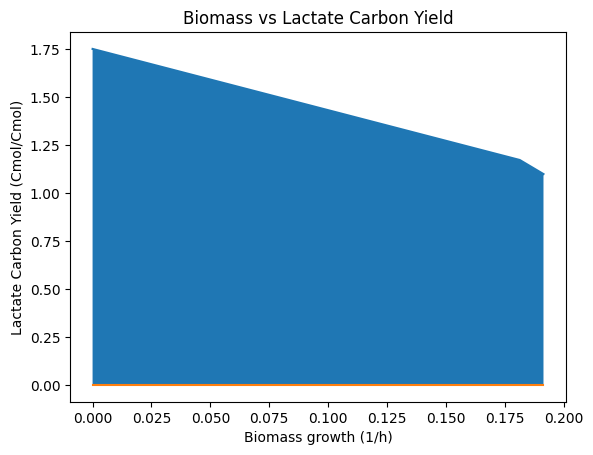

In [20]:
# EX0002: L_Lactate[e] --> 

prod_env = carbon_yield_calcs(model, set(), 'EX0002', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Lactate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Lactate Carbon Yield")
plt.show()

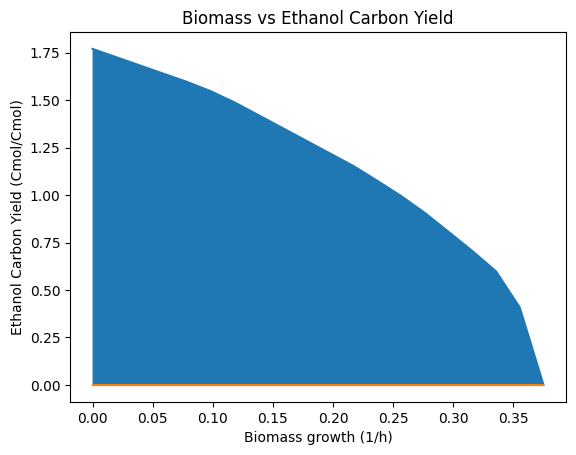

In [17]:
prod_env = carbon_yield_calcs(model, {'PYRDC', 'ALCD2x'}, 'EX0036', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethanol Carbon Yield")
plt.show()

In [ ]:
for met in model.metabolites:
    print(met)

(2E)_Octadecenoyl_ACP[c]
(3R)_3_Hydroxybutanoyl_ACP[c]
(3R)_3_Hydroxydecanoyl_ACP[c]
(3R)_3_Hydroxyoctanoyl_ACP[c]
(3R)_3_Hydroxypalmitoyl_ACP[c]
(3R)_3_Hydroxytetradecanoyl_ACP[c]
(R)_3_Amino_2_methylpropanoate[c]
(R)_3_Hydroxy_3_methyl_2_oxopentanoate[c]
(R)_3_Hydroxybutanoate[c]
(R)_3_Hydroxybutanoate[e]
(R)_3_Hydroxydodecanoyl_ACP[c]
(R)_3_Hydroxyoctadecanoyl_ACP[c]
(R)_3_Ureidoisobutyrate[c]
(R)_4_Phosphopantothenoyl_L_cysteine[c]
(R)_5_6_Dihydrothymine[c]
(R)_5_Diphosphomevalonate[c]
(R)_5_Phosphomevalonate[c]
(R)_Mevalonate[c]
(S)_2_Acetolactate[c]
(S)_3_Hydroxybutanoyl_CoA[c]
(S)_3_Hydroxydodecanoyl_CoA[c]
(S)_3_Hydroxyhexadecanoyl_CoA[c]
(S)_3_Hydroxyoctanoyl_CoA[c]
(S)_3_Hydroxytetradecanoyl_CoA[c]
(S)_Hydroxydecanoyl_CoA[c]
(S)_Hydroxyhexanoyl_CoA[c]
10_Formyl_THF[c]
1_(2_carboxyphenylamino)_1_deoxyribulose_5_phosphate[c]
1_2_Diacyl_sn_glycerol[c]
1_3_Bisphospho_D_glycerate[c]
1_4_Dihydroxy_2_naphthoyl_CoA[c]
1_Acyl_sn_glycero_3_phosphocholine[c]
1_Acyl_sn_glycero_3_phosphoe

Text(0.5, 1.0, 'Biomass vs Propanol Carbon Yield')

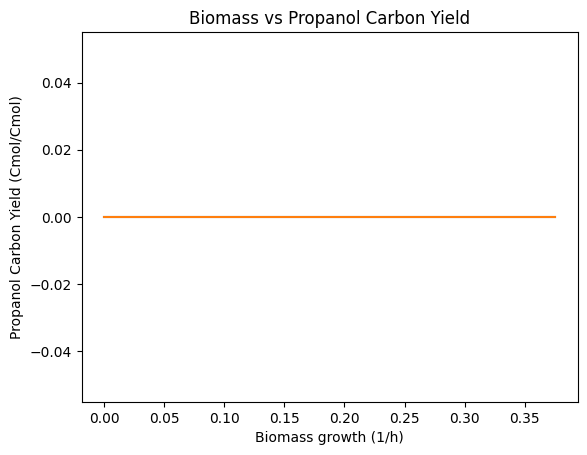

In [18]:
# ppoh,propanol,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir']",ppoh,alcohol,['oaa'],"('PMC', 'PMC3497732')","The key precursor, based on the included reactions is oaa.",C3H8O,,,,,,,

# add exchange rxn for propanol

ex_ppoh = Reaction('EX_ppoh', lower_bound=0.0, upper_bound=1000.0)
ex_ppoh.add_metabolites({model.metabolites.get_by_id('ppoh_c'): -1.0})
model.add_reactions([ex_ppoh])
heterologous_rxns.add('EX_ppoh')

prod_env = carbon_yield_calcs(model, {'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir'}, 'EX_ppoh', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Propanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Propanol Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Propanol Carbon Yield')

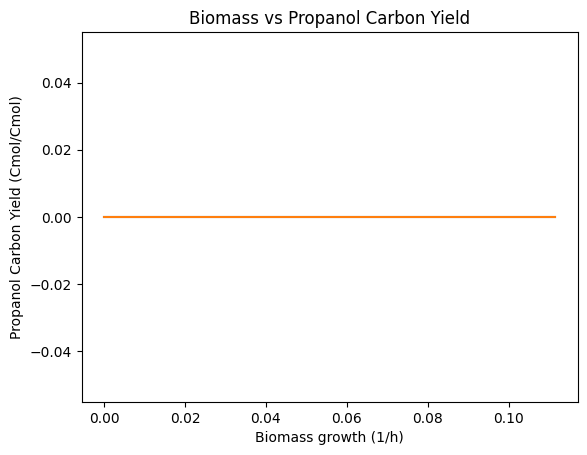

In [ ]:
# btoh,butanol,"['ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'ALCD4']",btoh,alcohol,accoa,"('PMC', 'PMC3126405')",,C4H10O,,,,,,,
# add exchange rxn for propanol

ex_btoh = Reaction('EX_btoh', lower_bound=0.0, upper_bound=1000.0)
ex_btoh.add_metabolites({model.metabolites.get_by_id('btoh_c'): -1.0})
model.add_reactions([ex_btoh])
heterologous_rxns.add('EX_btoh')

prod_env = carbon_yield_calcs(model, {'ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'ALCD4'}, 'EX_btoh', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Propanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Propanol Carbon Yield")

In [ ]:
with model:
    # carbon lockdown ONLY — skip the heterologous block
    for ex in model.exchanges:
        met = next(iter(ex.metabolites))
        if met.elements.get('C',0) and ex.id != 'EX0001':
            ex.lower_bound = 0.0
    model.reactions.EX0001.lower_bound = -1.0
    model.reactions.EX0004.bounds = (-1000, 0)
    model.objective = 'EXBiomass'
    print('growth, carbon-locked, NO het-block:', round(model.slim_optimize(),3))

    # now add the block back, exactly as the envelope does
    for r in heterologous_rxns:
        model.reactions.get_by_id(r).bounds = (0,0)
    print('growth, carbon-locked, WITH het-block:', round(model.slim_optimize(),3))

growth, carbon-locked, NO het-block: 0.111
growth, carbon-locked, WITH het-block: 0.111


In [ ]:
m = cobra.io.read_sbml_model("ModelFiles/iBag597.xml")   # fresh, no heterologous edits
print('bare optimize:', round(m.slim_optimize(), 3))
print('EX0001 bounds:', m.reactions.EX0001.bounds)
print('EX0004 bounds:', m.reactions.EX0004.bounds)

bare optimize: 0.355
EX0001 bounds: (-1.0, 1000.0)
EX0004 bounds: (-1.0, 1000.0)
